## Functions

In [10]:
import os
import pandas as pd
import xarray as xr
import geopandas as gpd
import rioxarray as rxr
import matplotlib.pyplot as plt
from dask.diagnostics import ProgressBar
import glob
from termcolor import cprint

In [ ]:

def convert_lon_0_360_to_neg180_180(da):
    lon = da['x']
    lon_new = (lon + 180) % 360 - 180  # converts 0-360 to -180 to 180
    da = da.assign_coords(x=lon_new)
    # sort by new longitude so data is ordered correctly
    da = da.sortby('x')
    return da

def print_colored(message, color='cyan'):
    colors = {
        'red': '\033[91m',
        'green': '\033[92m',
        'yellow': '\033[93m',
        'blue': '\033[94m',
        'magenta': '\033[95m',
        'cyan': '\033[96m',
        'endc': '\033[0m',
    }
    print(f"{colors.get(color, colors['cyan'])}{message}{colors['endc']}")

def check_aggregation_correctness(
    raw_folder, agg_folder,
    raw_template, agg_template,
    shapefile_path, shapefile_id_col,
    years=None,
    order_cols=['order_1', 'order_2', 'order_3', 'order_4'],
    column_to_plot='order_1',
    column_to_plot_avg='order_1_avg',
    raw_var_name='tas',
    plot_vmin=-5,
    plot_vmax=30,
    lon_bounds=(-130, -65),
    lat_bounds=(23, 50),
):
    print_colored("Step 1: Loading shapefile...", 'yellow')
    usa_counties = gpd.read_file(shapefile_path)
    usa_counties[shapefile_id_col] = usa_counties[shapefile_id_col].astype(int)

    if years is None:
        print_colored("No years provided, detecting years from aggregated data files...", 'yellow')
        files = os.listdir(agg_folder)
        years = []
        for f in files:
            if f.endswith('.csv'):
                import re
                m = re.search(r'(\d{4})', f)
                if m:
                    years.append(int(m.group(1)))
        years = sorted(set(years))
        if not years:
            raise ValueError("No years found in aggregated folder filenames.")
    print_colored(f"Years to process: {years}", 'green')

    print_colored("Step 2: Loading and concatenating aggregated county data...", 'yellow')
    agg_dfs = []
    for yr in years:
        fp = os.path.join(agg_folder, agg_template.format(yr))
        print_colored(f"  Loading aggregated file for year {yr}: {fp}", 'blue')
        df = pd.read_csv(fp)
        df['year'] = yr
        agg_dfs.append(df)
    agg_df = pd.concat(agg_dfs)
    print_colored(f"  Aggregated data loaded with shape {agg_df.shape}", 'green')

    print_colored("Step 3: Checking for NA counties in aggregated data...", 'yellow')
    na_poly_ids = agg_df[agg_df[order_cols].isnull().any(axis=1)]['poly_id'].unique()
    num_na_counties = len(na_poly_ids)
    filtered_df = agg_df[~agg_df['poly_id'].isin(na_poly_ids)]
    remaining_na_counties = filtered_df[filtered_df.isnull().any(axis=1)]['poly_id'].nunique()

    print_colored(f"  1. Counties with NA in any {order_cols}: {num_na_counties}", 'red')
    print_colored(f"  2. NA counties remaining after exclusion: {remaining_na_counties}", 'red')

    print_colored("Step 4: Loading and averaging raw grid data across all years...", 'yellow')
    raw_datasets = []
    for yr in years:
        raw_fp = os.path.join(raw_folder, raw_template.format(yr))
        print_colored(f"  Loading raw file for year {yr}: {raw_fp}", 'blue')
        ext = os.path.splitext(raw_fp)[1].lower()
        if ext in ['.tif', '.tiff']:
            ds = rxr.open_rasterio(raw_fp, masked=True).squeeze()
            if 'time' in ds.dims:
                ds = ds.mean(dim='time', skipna=True)
            elif 'band' in ds.dims:
                ds = ds.mean(dim='band', skipna=True)
            raw_datasets.append(ds)
        elif ext in ['.nc', '.grib']:
            ds = xr.open_dataset(raw_fp)
            if raw_var_name in ds.data_vars:
                da = ds[raw_var_name]
                if 'time' in da.dims:
                    da = da.mean(dim='time', skipna=True)
                raw_datasets.append(da)
            else:
                raise ValueError(f"Variable '{raw_var_name}' not found in {raw_fp}")
        else:
            raise ValueError(f"Unsupported raw data format {ext} for file {raw_fp}")
    raw_stack = xr.concat(raw_datasets, dim='year')
    raw_avg = raw_stack.mean(dim='year', skipna=True)
    if raw_var_name.lower() in ['tas', 'temperature', 'temp'] and raw_avg.max() > 100:
        raw_avg = raw_avg - 273.15
    raw_avg = convert_lon_0_360_to_neg180_180(raw_avg)
    print_colored(f"  Raw grid data averaged over years {years[0]}-{years[-1]}", 'green')

    print_colored("Step 5: Averaging aggregated county data across all years...", 'yellow')
    agg_avg_df = filtered_df.groupby('poly_id')[column_to_plot_avg].mean().reset_index()
    merged = usa_counties.merge(agg_avg_df, how='left', left_on=shapefile_id_col, right_on='poly_id')
    print_colored(f"  Aggregated county data averaged for plotting", 'green')

    print("raw data dimensions:")
    print(raw_avg.dims)
    print(raw_avg.shape)

    print(f"x min/max: {raw_avg['x'].min().item()}, {raw_avg['x'].max().item()}")
    print(f"y min/max: {raw_avg['y'].min().item()}, {raw_avg['y'].max().item()}")


    print_colored("Step 6: Plotting side-by-side maps...", 'yellow')
    fig, axs = plt.subplots(1, 2, figsize=(18, 9))
    with ProgressBar():
        raw_avg.plot(ax=axs[0], cmap='coolwarm', vmin=plot_vmin, vmax=plot_vmax)
    usa_counties.boundary.plot(ax=axs[0], color='black', linewidth=0.3)
    axs[0].set_title(f"Raw Grid Data Average {years[0]}-{years[-1]}")
    axs[0].set_xlim(lon_bounds)
    axs[0].set_ylim(lat_bounds)
    axs[0].axis('off')

    merged.plot(column=column_to_plot_avg, ax=axs[1], cmap='coolwarm', vmin=plot_vmin, vmax=plot_vmax, legend=True)
    axs[1].set_title(f"Aggregated County Data Average {years[0]}-{years[-1]}")
    axs[1].set_xlim(lon_bounds)
    axs[1].set_ylim(lat_bounds)
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()
    print_colored("Done!", 'green')


In [13]:

def plot_na_counties(
    agg_folder,
    agg_template,
    shapefile_path,
    shapefile_id_col="GEOID",
    years=None,
    order_cols=None
):
    cprint("🧭 Loading shapefile...", "cyan")
    counties_gdf = gpd.read_file(shapefile_path)
    counties_gdf[shapefile_id_col] = counties_gdf[shapefile_id_col].astype(str)

    cprint("📥 Reading aggregated data...", "cyan")
    dfs = []
    for y in years:
        file_path = os.path.join(agg_folder, agg_template.format(y))
        if os.path.exists(file_path):
            df = pd.read_csv(file_path, dtype={"poly_id": str})
            df["year"] = y
            dfs.append(df)
        else:
            cprint(f"⚠️  Missing: {file_path}", "yellow")

    if not dfs:
        raise ValueError("No files found or loaded.")

    agg_df = pd.concat(dfs, ignore_index=True)

    if order_cols is None:
        order_cols = [col for col in agg_df.columns if col.startswith("order_")]

    cprint(f"🔍 Checking for NAs in columns: {order_cols}", "cyan")
    agg_df["has_na"] = agg_df[order_cols].isna().any(axis=1)

    cprint("🧬 Merging with shapefile...", "cyan")
    merged_gdf = counties_gdf.merge(agg_df[["poly_id", "has_na"]].drop_duplicates(), 
                                     left_on=shapefile_id_col, 
                                     right_on="poly_id", 
                                     how="left")

    merged_gdf["has_na"] = merged_gdf["has_na"].fillna(False)

    cprint("🖼️  Plotting counties with NAs in red...", "cyan")
    fig, ax = plt.subplots(figsize=(12, 8))
    merged_gdf.plot(ax=ax, color="lightgray", edgecolor="black", linewidth=0.2)
    merged_gdf[merged_gdf["has_na"]].plot(ax=ax, color="red", linewidth=0.2)
    ax.set_title("Counties with ≥1 NA in any 'order_' column", fontsize=14)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

    cprint(f"✅ Done. Total counties with NA: {merged_gdf['has_na'].sum()}", "green")


## Calls

Step 1: Loading shapefile...
Years to process: range(2000, 2005)
Step 2: Loading and concatenating aggregated county data...
  Loading aggregated file for year 2000: /global/scratch/users/yougsanghvi/aggregated_results_gdnat_usa/gdnat_usa_agg_2000.csv
  Loading aggregated file for year 2001: /global/scratch/users/yougsanghvi/aggregated_results_gdnat_usa/gdnat_usa_agg_2001.csv
  Loading aggregated file for year 2002: /global/scratch/users/yougsanghvi/aggregated_results_gdnat_usa/gdnat_usa_agg_2002.csv
  Loading aggregated file for year 2003: /global/scratch/users/yougsanghvi/aggregated_results_gdnat_usa/gdnat_usa_agg_2003.csv
  Loading aggregated file for year 2004: /global/scratch/users/yougsanghvi/aggregated_results_gdnat_usa/gdnat_usa_agg_2004.csv
  Aggregated data loaded with shape (193690, 11)
Step 3: Checking for NA counties in aggregated data...
  1. Counties with NA in any ['order_1', 'order_2', 'order_3', 'order_4']: 97
  2. NA counties remaining after exclusion: 0
Step 4: Load

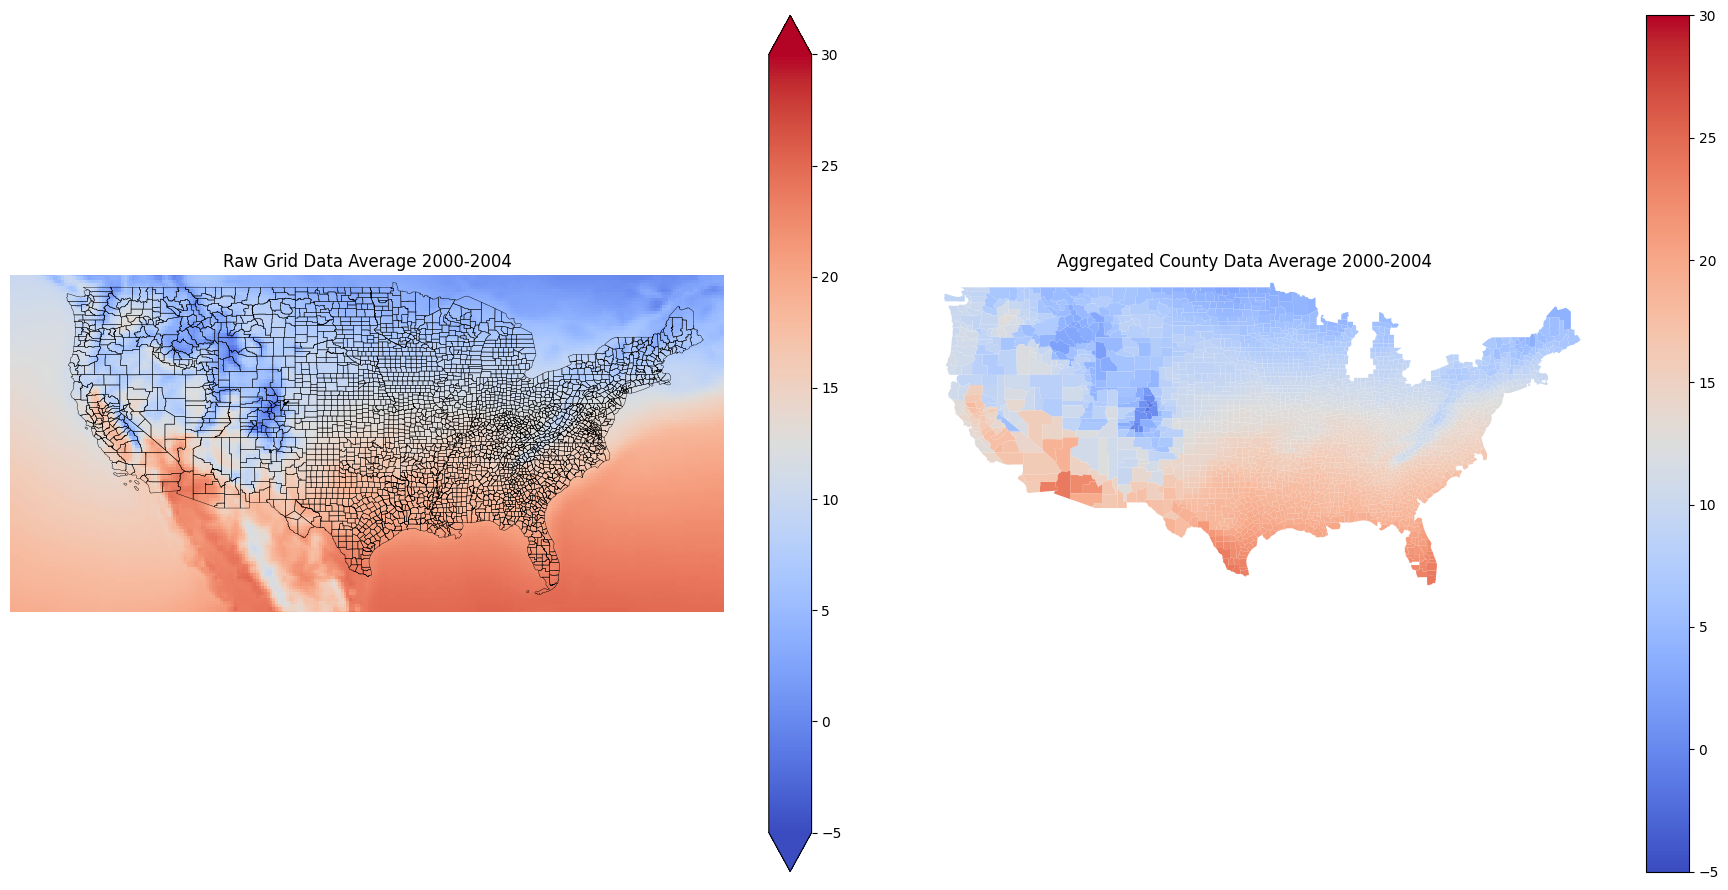

Done!


In [8]:
check_aggregation_correctness(
    raw_folder="/global/scratch/users/yougsanghvi/gdnat_tiff_files_by_yr",
    agg_folder="/global/scratch/users/yougsanghvi/aggregated_results_gdnat_usa",
    raw_template="gdnat_{}.tif",
    agg_template="gdnat_usa_agg_{}.csv",
    shapefile_path="/global/scratch/users/yougsanghvi/shapefiles/tl_2016_us_county_mortality.shp",
    shapefile_id_col="GEOID",
    years=range(2000, 2005)
)


🧭 Loading shapefile...
📥 Reading aggregated data...
🔍 Checking for NAs in columns: ['order_1', 'order_2', 'order_3', 'order_4', 'order_1_avg', 'order_2_avg', 'order_3_avg', 'order_4_avg']
🧬 Merging with shapefile...
🖼️  Plotting counties with NAs in red...


/tmp/ipykernel_928042/849761357.py:41: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged_gdf["has_na"] = merged_gdf["has_na"].fillna(False)


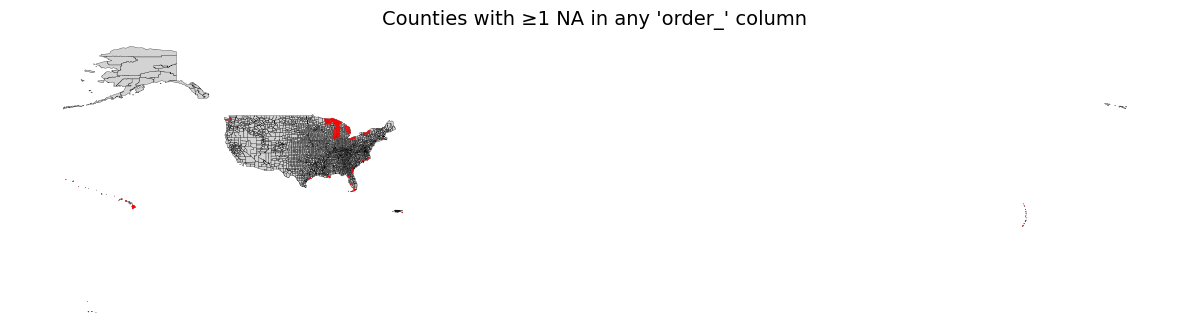

✅ Done. Total counties with NA: 76


In [14]:
plot_na_counties(
    agg_folder="/global/scratch/users/yougsanghvi/aggregated_results_gdnat_usa",
    agg_template="gdnat_usa_agg_{}.csv",
    shapefile_path="/global/scratch/users/yougsanghvi/shapefiles/tl_2016_us_county_mortality.shp",
    shapefile_id_col="GEOID",
    years=range(2000, 2005)
)
